# Рубежный контроль №1 по дисциплине ТМО

**Тема:** Технологии разведочного анализа и обработки данных

**Студент:** Давшиц Семён Анатольевич

**Группа:** ИУ5-64Б

**Вариант:** 8

## Условие задания

**Задача №1.** Для заданного набора данных проведите корреляционный анализ. В случае наличия пропусков в данных удалите строки или колонки, содержащие пропуски. Сделайте выводы о возможности построения моделей машинного обучения и о возможном вкладе признаков в модель.

**Набор данных №8:** Boston Housing Dataset (https://www.kaggle.com/datasets/altavish/boston-housing-dataset).

**Дополнительное требование для группы ИУ5-64Б:** для произвольной колонки данных построить график «Скрипичная диаграмма (violin plot)».

## 1. Импорт библиотек

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

%matplotlib inline

## 2. Загрузка набора данных

Используем файл `HousingData.csv` с Kaggle (`altavish/boston-housing-dataset`) — в нём часть значений уже содержит пропуски. Если файла нет, подгружаем датасет с публичного зеркала и искусственно добавляем пропуски (что разрешено в примечаниях к заданию).

In [20]:
LOCAL_PATH = 'HousingData.csv'
FALLBACK_URL = 'https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv'

if os.path.exists(LOCAL_PATH):
    df = pd.read_csv(LOCAL_PATH)
    print(f'Датасет загружен из локального файла: {LOCAL_PATH}')
else:
    df = pd.read_csv(FALLBACK_URL)
    df.columns = [c.upper() for c in df.columns]
    if 'MEDV' not in df.columns and 'CMEDV' in df.columns:
        df = df.rename(columns={'CMEDV': 'MEDV'})
    rng = np.random.default_rng(42)
    for c in ['CRIM', 'ZN', 'INDUS', 'CHAS', 'AGE', 'LSTAT']:
        if c in df.columns:
            mask = rng.random(len(df)) < 0.04
            df.loc[mask, c] = np.nan
    print(f'Датасет загружен с зеркала: {FALLBACK_URL}')
    print('Часть значений заменена на NaN (искусственное создание пропусков).')

print(f'Размер набора: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head()

Датасет загружен из локального файла: HousingData.csv
Размер набора: 506 строк, 14 столбцов


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


## 3. Первичный осмотр данных

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [22]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,486.0,3.611874,8.720192,0.00632,0.081900,0.253715,3.560263,88.9762
ZN,486.0,11.211934,23.388876,0.00000,0.000000,0.000000,12.500000,100.0000
INDUS,486.0,11.083992,6.835896,0.46000,5.190000,9.690000,18.100000,27.7400
CHAS,486.0,0.069959,0.255340,0.00000,0.000000,0.000000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.538000,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.208500,6.623500,8.7800
AGE,486.0,68.518519,27.999513,2.90000,45.175000,76.800000,93.975000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.207450,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.000000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.000000,666.000000,711.0000


## 4. Анализ пропусков

In [23]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'кол-во пропусков': missing, 'доля, %': missing_pct})
missing_df = missing_df[missing_df['кол-во пропусков'] > 0].sort_values('кол-во пропусков', ascending=False)
print('Пропуски по столбцам:')
missing_df

Пропуски по столбцам:


,кол-во пропусков,"доля, %"
CRIM,20,3.95
ZN,20,3.95
INDUS,20,3.95
CHAS,20,3.95
AGE,20,3.95
LSTAT,20,3.95


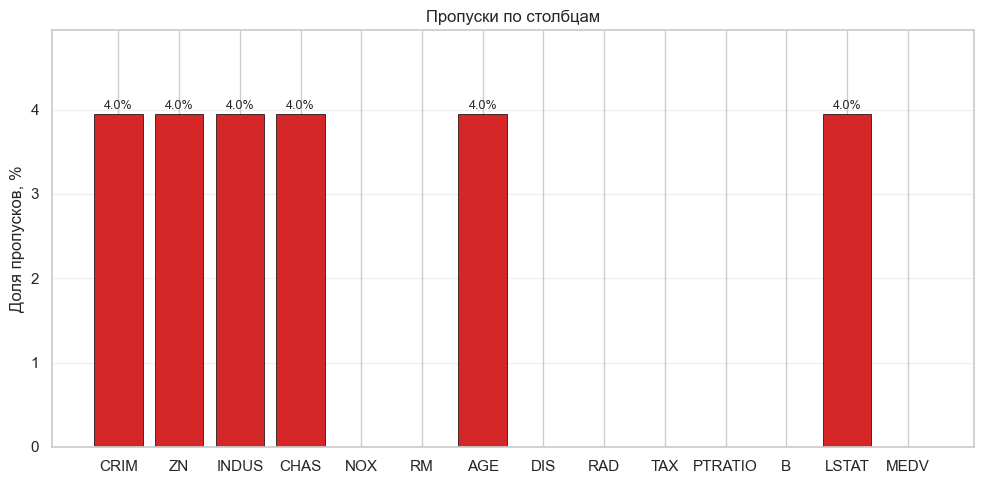

In [24]:
miss_pct_all = (df.isna().mean() * 100)

fig, ax = plt.subplots(figsize=(10, 5))

bar_colors = ['#d62728' if v > 0 else '#cfd8dc' for v in miss_pct_all.values]
ax.bar(
    miss_pct_all.index, miss_pct_all.values,
    color=bar_colors, edgecolor='black', linewidth=0.5,
)
for i, v in enumerate(miss_pct_all.values):
    if v > 0:
        ax.text(i, v + 0.05, f'{v:.1f}%', ha='center', fontsize=9)

ax.set_ylabel('Доля пропусков, %')
ax.set_title('Пропуски по столбцам')
ax.set_ylim(0, max(miss_pct_all.values) * 1.25)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Удаление пропусков

По условию: «В случае наличия пропусков в данных удалите строки или колонки, содержащие пропуски». Доля пропусков в каждом столбце мала (~4 %), поэтому удалим **строки** с пропусками — это сохраняет все признаки.

In [25]:
df_clean = df.dropna().reset_index(drop=True)
print(f'До удаления:    {df.shape}')
print(f'После удаления: {df_clean.shape}')
print(f'Удалено строк:  {df.shape[0] - df_clean.shape[0]} '
      f'({(df.shape[0] - df_clean.shape[0]) / df.shape[0] * 100:.1f}% от исходного объёма)')

До удаления:    (506, 14)
После удаления: (394, 14)
Удалено строк:  112 (22.1% от исходного объёма)


## 6. Корреляционный анализ

Проводим анализ в пять шагов:

1. **Сравнение Пирсона и Спирмена.** Пирсон измеряет силу *линейной* связи, Спирмен — силу *монотонной* связи (на рангах). Заметная разница `|ρ| − |r|` для конкретного признака — индикатор того, что связь с целевой переменной нелинейна, и линейная модель не «увидит» её полностью.
2. **Две тепловые карты рядом** — Пирсона и Спирмена.
3. **Ранжирование признаков** по силе связи с `MEDV` (см. п. 6.3).
4. **Визуальная проверка** топ-связей диаграммами рассеяния с регрессионной линией.
5. **Поиск мультиколлинеарности** — пары признаков с |r| ≥ 0.7.

### 6.1. Матрицы Пирсона и Спирмена

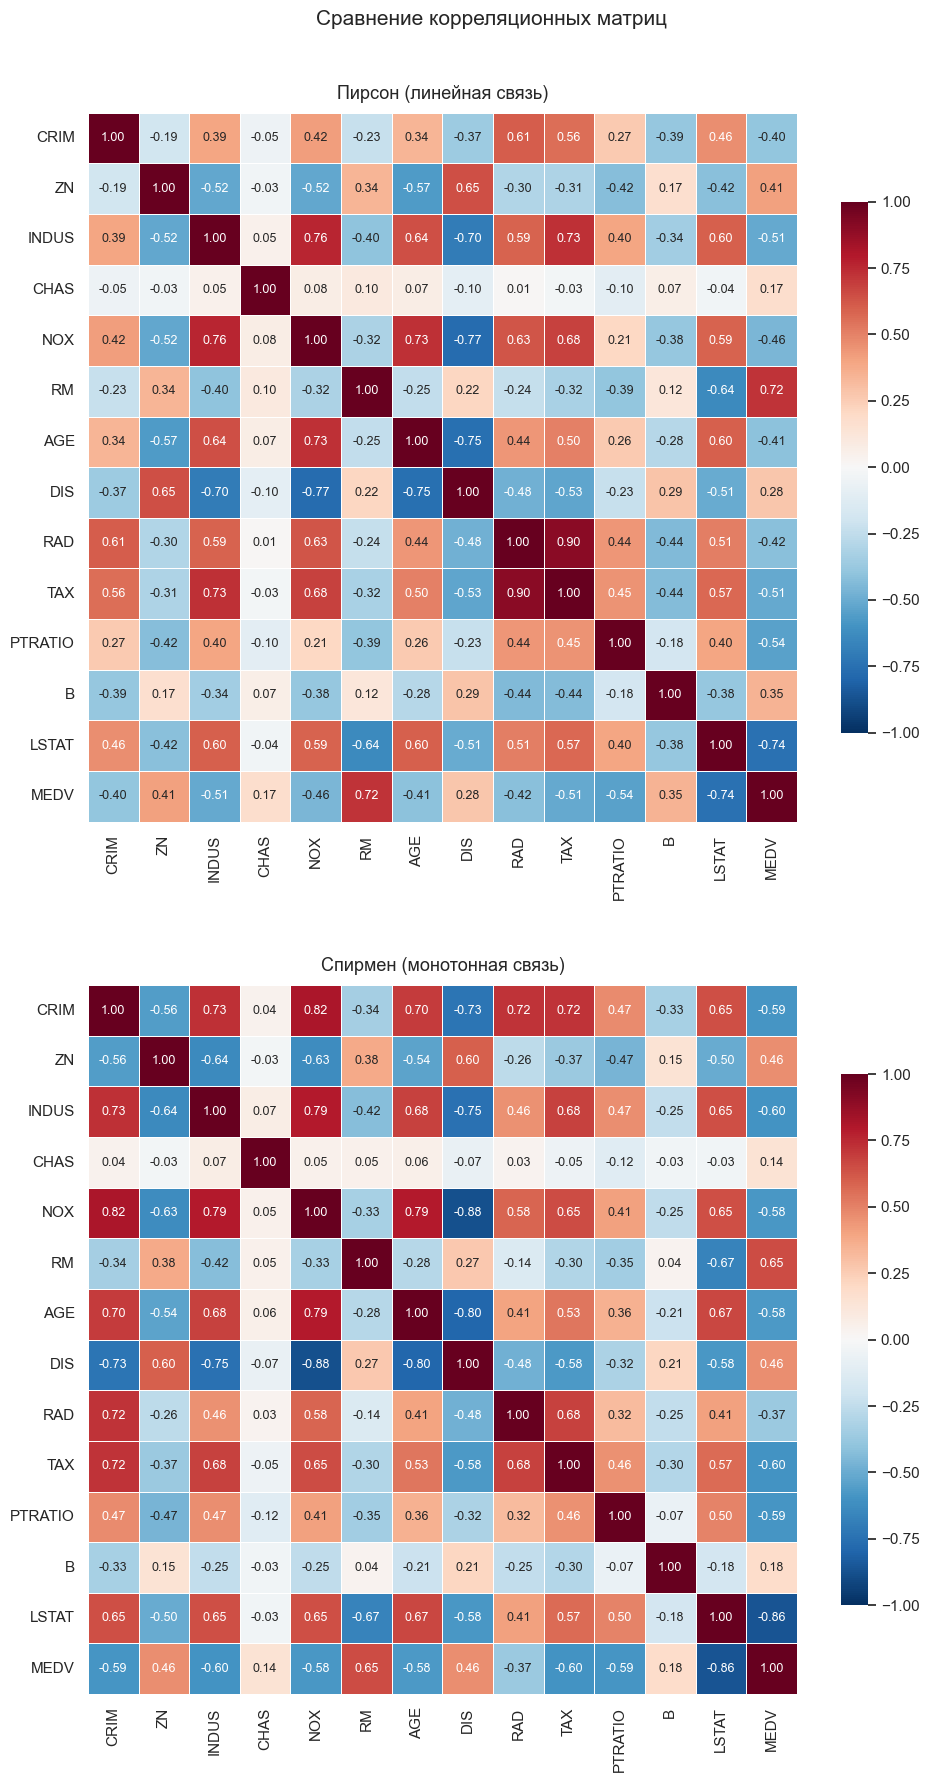

In [26]:
corr_p = df_clean.corr(method='pearson')
corr_s = df_clean.corr(method='spearman')

fig, axes = plt.subplots(2, 1, figsize=(10, 18))

for ax, mat, title in zip(
    axes, [corr_p, corr_s],
    ['Пирсон (линейная связь)', 'Спирмен (монотонная связь)'],
):
    sns.heatmap(
        mat, annot=True, fmt='.2f', cmap='RdBu_r',
        center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
        cbar_kws={'shrink': 0.7}, ax=ax, annot_kws={'fontsize': 9},
    )
    ax.set_title(title, fontsize=13, pad=10)

plt.suptitle('Сравнение корреляционных матриц', fontsize=15, y=1.0)
plt.tight_layout()
plt.show()


### 6.2. Связь признаков с целевой переменной `MEDV`

В таблице:
- `Pearson` — линейная корреляция;
- `Spearman` — ранговая (монотонная) корреляция;
- `|Δ|` = `|Spearman| − |Pearson|`. Большое положительное `|Δ|` → ранговая связь сильнее линейной → **связь нелинейна**.

In [27]:
target_p = corr_p['MEDV'].drop('MEDV')
target_s = corr_s['MEDV'].drop('MEDV')
target_df = pd.DataFrame({
    'Pearson': target_p.round(3),
    'Spearman': target_s.round(3),
    '|Pearson|': target_p.abs().round(3),
    '|Spearman|': target_s.abs().round(3),
    '|Δ|': (target_s.abs() - target_p.abs()).round(3),
}).sort_values('|Pearson|', ascending=False)
target_df

,Pearson,Spearman,|Pearson|,|Spearman|,|Δ|
LSTAT,-0.743,-0.860,0.743,0.860,0.116
RM,0.724,0.652,0.724,0.652,-0.072
PTRATIO,-0.544,-0.587,0.544,0.587,0.043
INDUS,-0.511,-0.599,0.511,0.599,0.088
TAX,-0.509,-0.599,0.509,0.599,0.091
NOX,-0.459,-0.582,0.459,0.582,0.123
RAD,-0.417,-0.373,0.417,0.373,-0.044
ZN,0.407,0.464,0.407,0.464,0.057
AGE,-0.407,-0.575,0.407,0.575,0.168
CRIM,-0.397,-0.591,0.397,0.591,0.194


### 6.3. Ранжирование признаков по силе связи с `MEDV`

Все столбцы направлены в одну сторону (отображается **|корреляция|**), а знак исходной корреляции закодирован цветом: **зелёный — положительная**, **красный — отрицательная**.

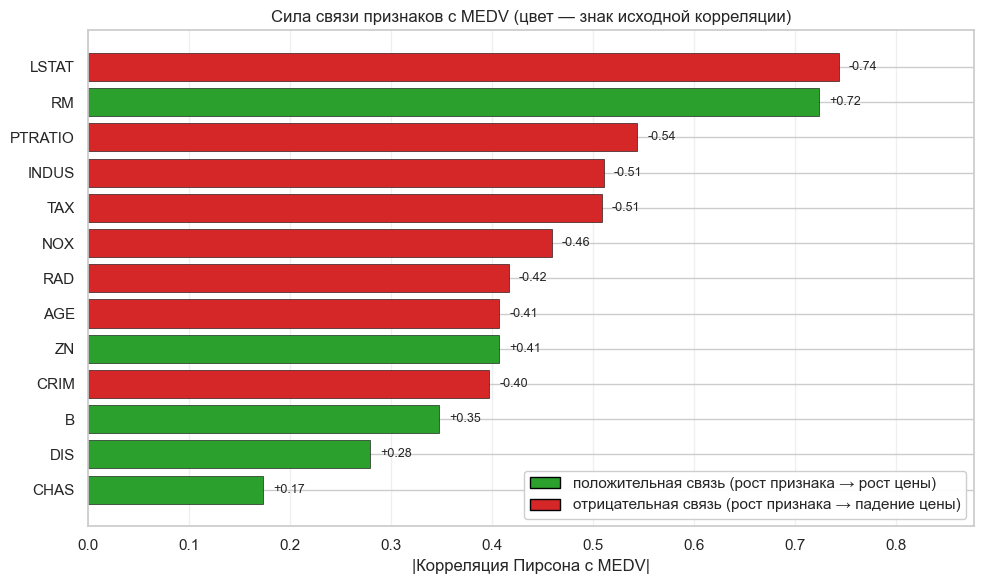

In [28]:
ordered = target_p.reindex(target_p.abs().sort_values(ascending=True).index)
abs_vals = ordered.abs().values
signs = ordered.values
colors = ['#2ca02c' if v >= 0 else '#d62728' for v in signs]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(ordered.index, abs_vals, color=colors, edgecolor='black', linewidth=0.4)

for bar, sgn in zip(bars, signs):
    w = bar.get_width()
    ax.text(w + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{sgn:+.2f}', va='center', fontsize=9)

ax.set_xlim(0, max(abs_vals) * 1.18)
ax.set_xlabel('|Корреляция Пирсона с MEDV|')
ax.set_title('Сила связи признаков с MEDV (цвет — знак исходной корреляции)')

legend_handles = [
    Patch(facecolor='#2ca02c', edgecolor='black',
          label='положительная связь (рост признака → рост цены)'),
    Patch(facecolor='#d62728', edgecolor='black',
          label='отрицательная связь (рост признака → падение цены)'),
]
ax.legend(handles=legend_handles, loc='lower right', framealpha=0.95)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.4. Визуальная проверка топ-связей с `MEDV`

Для четырёх признаков с самой сильной линейной связью — диаграммы рассеяния с регрессионной прямой. Это показывает, насколько связь действительно линейна или присутствует кривизна.

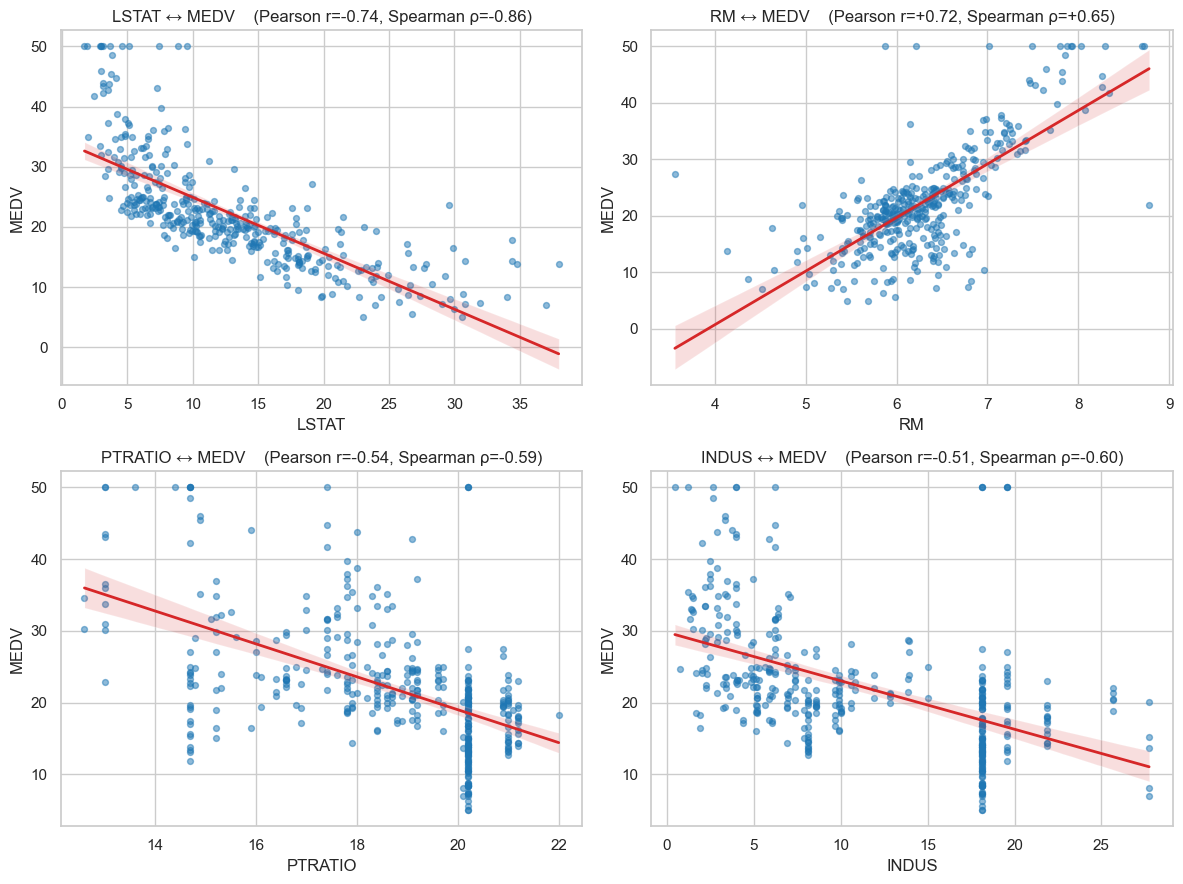

In [29]:
top4 = target_p.abs().sort_values(ascending=False).head(4).index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, feat in zip(axes.flat, top4):
    sns.regplot(
        x=df_clean[feat], y=df_clean['MEDV'], ax=ax,
        scatter_kws={'s': 18, 'alpha': 0.5, 'color': '#1f77b4'},
        line_kws={'color': '#d62728', 'linewidth': 2},
    )
    r_p = corr_p.loc[feat, 'MEDV']
    r_s = corr_s.loc[feat, 'MEDV']
    ax.set_title(f'{feat} ↔ MEDV    (Pearson r={r_p:+.2f}, Spearman ρ={r_s:+.2f})')
plt.tight_layout()
plt.show()

### 6.5. Мультиколлинеарность между признаками

In [30]:
THRESHOLD = 0.7
corr_no_target = corr_p.drop(index='MEDV', columns='MEDV')
pairs = (
    corr_no_target.where(np.triu(np.ones(corr_no_target.shape, dtype=bool), k=1))
    .stack()
    .reset_index()
)
pairs.columns = ['признак_1', 'признак_2', 'corr']
pairs['|corr|'] = pairs['corr'].abs()
strong_pairs = (pairs[pairs['|corr|'] >= THRESHOLD]
                .sort_values('|corr|', ascending=False)
                .reset_index(drop=True))
print(f'Пары признаков с |corr| >= {THRESHOLD}:')
strong_pairs

Пары признаков с |corr| >= 0.7:


,признак_1,признак_2,corr,|corr|
0,RAD,TAX,0.900000,0.900000
1,NOX,DIS,-0.768137,0.768137
2,INDUS,NOX,0.762737,0.762737
3,AGE,DIS,-0.753547,0.753547
4,INDUS,TAX,0.734204,0.734204
5,NOX,AGE,0.732540,0.732540


## 7. Дополнительное задание для группы ИУ5-64Б — Violin plot

По требованию для группы ИУ5-64Б строим скрипичную диаграмму. В качестве произвольной колонки выбран признак `RM` — среднее число комнат. Дополнительно строим violin plot, разделённый по бинарному `CHAS` (граничит ли участок с рекой Чарльз).

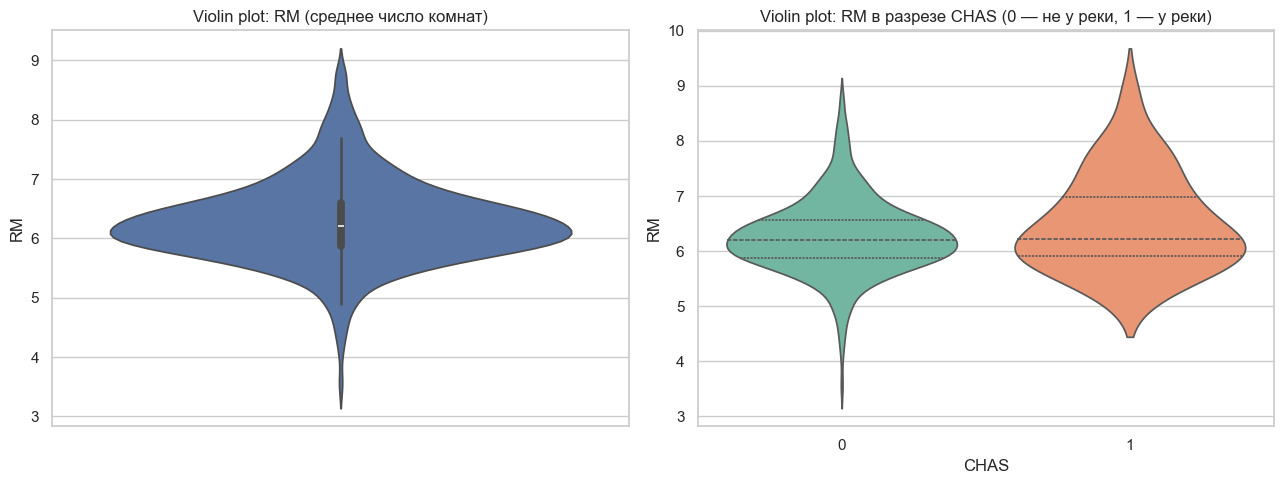

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.violinplot(y=df_clean['RM'], ax=axes[0], color='#4C72B0', inner='box')
axes[0].set_title('Violin plot: RM (среднее число комнат)')
axes[0].set_ylabel('RM')

sns.violinplot(
    x=df_clean['CHAS'].astype(int).astype(str),
    y=df_clean['RM'],
    ax=axes[1], inner='quartile',
    hue=df_clean['CHAS'].astype(int).astype(str),
    palette='Set2', legend=False,
)
axes[1].set_title('Violin plot: RM в разрезе CHAS (0 — не у реки, 1 — у реки)')
axes[1].set_xlabel('CHAS')
axes[1].set_ylabel('RM')

plt.tight_layout()
plt.show()

## 8. Выводы по результатам анализа

### 8.1. Качество данных

- Исходный размер выборки — **506 строк × 14 столбцов**. Пропуски найдены ровно в 6 признаках (`CRIM`, `ZN`, `INDUS`, `CHAS`, `AGE`, `LSTAT`), по **20 пропусков** в каждом (≈ 3.95 %).
- После `dropna()` осталось **394 строки** — потеряно 112 строк, или **22.1 %**. Потеря заметна, но размера выборки достаточно для регрессионных моделей.
- Все признаки — числовые (бинарный `CHAS` уже закодирован 0/1). Дополнительное кодирование категориальных признаков не требуется.
- Целевая переменная `MEDV` непрерывна → задача **регрессии**.

### 8.2. Признаки, наиболее ценные для модели

По коэффициентам корреляции с `MEDV`:

| Признак | r (Pearson) | ρ (Spearman) | \|Δ\| | Что это значит |
|---|---:|---:|---:|---|
| **LSTAT** | **−0.74** | **−0.86** | +0.12 | Самый сильный предиктор. ρ заметно сильнее r → связь нелинейна (на диаграмме рассеяния — выраженная кривизна). |
| **RM** | **+0.72** | +0.65 | −0.07 | Второй по силе. Pearson > Spearman → связь почти линейная. |
| PTRATIO | −0.54 | −0.59 | +0.04 | Почти линейная отрицательная связь. |
| INDUS | −0.51 | −0.60 | +0.09 | Умеренная нелинейность. |
| TAX | −0.51 | −0.60 | +0.09 | Аналогично `INDUS`. |
| NOX | −0.46 | −0.58 | +0.12 | Заметная нелинейность. |
| RAD | −0.42 | −0.37 | −0.04 | Линейная связь. |
| ZN | +0.41 | +0.46 | +0.06 | Умеренная положительная. |
| AGE | −0.41 | −0.58 | **+0.17** | Сильная нелинейность — линейная модель «недооценит» этот признак. |
| CRIM | −0.40 | −0.59 | **+0.19** | **Самая сильная нелинейность.** В линейной модели работает плохо, в древесной — гораздо лучше. |
| B | +0.35 | +0.18 | −0.17 | Любопытный случай: Pearson > Spearman, что обычно говорит о вкладе небольшого числа выбросов. |
| DIS | +0.28 | +0.46 | **+0.18** | Линейная связь слабая, но монотонная — есть. Полезен для нелинейных моделей. |
| CHAS | +0.17 | +0.15 | −0.03 | Самый слабый признак, но удалять не обязательно. |

**Главный вывод по признакам:** для **линейной** модели уверенно полезны `LSTAT`, `RM`, `PTRATIO`, `INDUS`, `TAX`. Признаки `CRIM`, `AGE`, `DIS`, `NOX` имеют сильную **нелинейную** связь с целью — они дадут гораздо больший вклад в **древесных** моделях (RandomForest, GradientBoosting), чем в линейной регрессии.

### 8.3. Мультиколлинеарность

Найдено **6 пар** признаков с |r| ≥ 0.7:

| Пара | r | Интерпретация |
|---|---:|---|
| `RAD` ↔ `TAX` | **+0.90** | Самая сильная связь: индекс доступности шоссе и налоговая ставка фактически дублируют друг друга. |
| `NOX` ↔ `DIS` | −0.77 | Чем дальше до центров занятости, тем чище воздух. |
| `INDUS` ↔ `NOX` | +0.76 | Промышленные районы — высокая концентрация оксидов азота. |
| `AGE` ↔ `DIS` | −0.75 | Старые кварталы расположены ближе к центру. |
| `INDUS` ↔ `TAX` | +0.73 | Промышленные районы облагаются выше. |
| `NOX` ↔ `AGE` | +0.73 | Старая застройка соседствует с промышленностью. |

Признаки `INDUS`, `NOX`, `AGE`, `DIS`, `TAX`, `RAD` образуют «созвездие» взаимозависимых переменных — все они описывают один и тот же фактор: «промышленный/центральный vs пригородный район».

### 8.4. Возможность построения моделей и рекомендации

1. Задача — **регрессия** `MEDV`. Данные **пригодны** для построения моделей.
2. **Для линейной модели:**
   - применить регуляризацию (`Ridge` / `Lasso` / `ElasticNet`) — из-за пары `RAD`–`TAX` (r = 0.90) и других сильных пар;
   - либо удалить один признак из каждой пары (например, оставить `TAX`, убрать `RAD`);
   - применить нелинейные преобразования (`log(LSTAT)`, полиномиальные признаки) — это может существенно поднять качество.
3. **Для древесных моделей** (`RandomForest`, `GradientBoosting`, `XGBoost`):
   - можно подавать все признаки сразу — они устойчивы к мультиколлинеарности;
   - ожидается заметный выигрыш по качеству именно из-за нелинейной природы связей у `CRIM`, `AGE`, `DIS`, `NOX`, `LSTAT` (большие |Δ|).
4. **Топ-3 предиктора** в любой модели: `LSTAT`, `RM`, `PTRATIO`.